In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings('ignore')

import psycopg
import pandas as pd
import mlflow
from catboost import CatBoostClassifier
from autofeat import AutoFeatClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import CatBoostEncoder
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

TABLE_NAME = 'clean_users_churn'
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = 'churn_laptev_ilya_sergeevich_2'
RUN_NAME = "feature_selection"
REGISTRY_MODEL_NAME = 'cb_with_autofeat'
FS_ASSETS = "fs_assets" 

In [2]:
connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

In [3]:
df.head(2)

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,2133,3023-GFLBR,2017-03-01,2019-12-01,Month-to-month,No,Credit card (automatic),86.15,2745.7,Fiber optic,...,No,No,No,Yes,Female,0,Yes,Yes,Yes,1
1,837,0727-BMPLR,2015-04-01,2019-11-01,One year,Yes,Electronic check,100.00,5509.3,Fiber optic,...,Yes,No,Yes,Yes,Female,1,No,No,Yes,1


In [5]:
cat_features = df.select_dtypes(include='object')
potential_binary_features = cat_features.nunique() == 2

binary_cat_features = cat_features[potential_binary_features[potential_binary_features].index]
other_cat_features = cat_features[potential_binary_features[~potential_binary_features].index]
num_features = df.select_dtypes(['float'])

preprocessor = ColumnTransformer([
    ('bin', OneHotEncoder(drop="if_binary"), binary_cat_features.columns.tolist()),
    ('cat', CatBoostEncoder(return_df=False), other_cat_features.columns.tolist()),
    ('num', StandardScaler(), num_features.columns.tolist())
], remainder='drop', verbose_feature_names_out=True)

X = pd.DataFrame(
    preprocessor.fit_transform(df.drop(columns="target"), df["target"]),
    columns=preprocessor.get_feature_names_out()
)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [7]:
# Отбор признаков
estimator = RandomForestClassifier(n_estimators=300)

sfs = SFS(
    estimator, k_features=10, forward=True, floating=False, 
    cv=4, n_jobs=-1, scoring="roc_auc"
)
sbs = SFS(
    estimator, k_features=10, forward=False, floating=False, 
    cv=4, n_jobs=-1, scoring="roc_auc"
)

sfs = sfs.fit(X_train, y_train)
sbs = sbs.fit(X_train, y_train)

In [8]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T 

In [9]:
os.mkdir(FS_ASSETS)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv")

In [12]:
top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

print('\nSequential Forward Selection (k=10)')
print('CV Score:')
print(sfs.k_score_)

print('\nSequential Backward Selection')
print('CV Score:')
print(sbs.k_score_)


Sequential Forward Selection (k=10)
CV Score:
0.8271936998906096

Sequential Backward Selection
CV Score:
0.8280636643409929


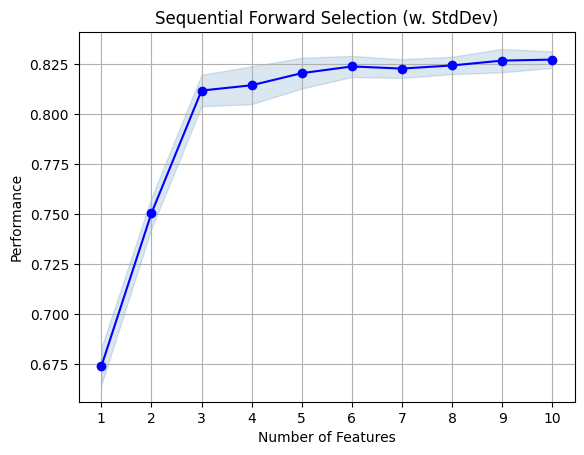

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sfs.png")

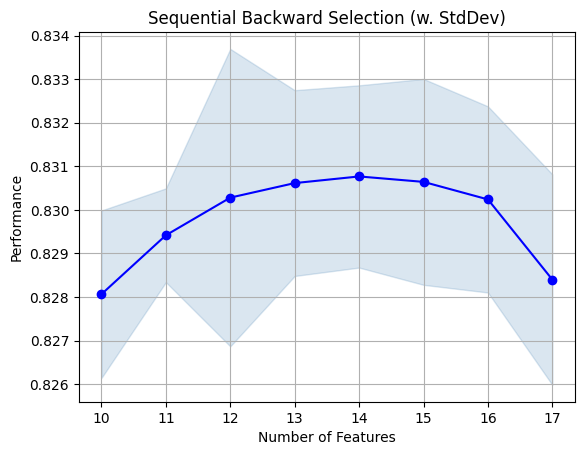

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sbs.png") 

In [15]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [16]:
interc_features

['num__monthly_charges',
 'bin__internet_service_Fiber optic',
 'cat__type',
 'num__total_charges',
 'cat__payment_method']

In [17]:
union_features

['bin__tech_support_Yes',
 'bin__multiple_lines_Yes',
 'bin__partner_Yes',
 'bin__paperless_billing_Yes',
 'bin__internet_service_Fiber optic',
 'bin__online_backup_Yes',
 'cat__type',
 'cat__payment_method',
 'bin__streaming_tv_Yes',
 'bin__online_security_Yes',
 'bin__dependents_Yes',
 'num__monthly_charges',
 'bin__gender_Male',
 'num__total_charges',
 'bin__streaming_movies_Yes']

In [18]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = 'https://storage.yandexcloud.net'
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv('AWS_ACCESS_KEY_ID')
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv('AWS_SECRET_ACCESS_KEY')

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

In [19]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS) 

print(run_id)

2024-11-10 13:40:16,382 INFO: Found credentials in environment variables.


641d8494c5414e2baacf719744ce8fa7


In [20]:
def get_metrics(y_true, y_pred, y_proba):
    from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, log_loss
    metrics = {}
    _, err1, _, err2 = confusion_matrix(y_test, y_pred, normalize='all').ravel()
    metrics["err1"] = err1
    metrics["err2"] = err2
    metrics["auc"] = roc_auc_score(y_test, y_proba)
    metrics["precision"] = precision_score(y_test, y_pred)
    metrics["recall"] = recall_score(y_test, y_pred)
    metrics["f1"] = f1_score(y_test, y_pred)
    metrics["logloss"] = log_loss(y_test, y_pred)
    return metrics

In [21]:
# Обучение модели на пересекающихся признаках
interc_model = CatBoostClassifier(auto_class_weights="Balanced", random_seed=42)
interc_model.fit(X_train[interc_features], y_train)

Learning rate set to 0.020938
0:	learn: 0.6848609	total: 58.9ms	remaining: 58.8s
1:	learn: 0.6773765	total: 65.4ms	remaining: 32.6s
2:	learn: 0.6686022	total: 68.2ms	remaining: 22.7s
3:	learn: 0.6616515	total: 70.7ms	remaining: 17.6s
4:	learn: 0.6550999	total: 78ms	remaining: 15.5s
5:	learn: 0.6502806	total: 82.4ms	remaining: 13.7s
6:	learn: 0.6434557	total: 84.9ms	remaining: 12s
7:	learn: 0.6360861	total: 87.8ms	remaining: 10.9s
8:	learn: 0.6296063	total: 90.5ms	remaining: 9.96s
9:	learn: 0.6231931	total: 99.2ms	remaining: 9.82s
10:	learn: 0.6171738	total: 102ms	remaining: 9.19s
11:	learn: 0.6112167	total: 105ms	remaining: 8.66s
12:	learn: 0.6059271	total: 108ms	remaining: 8.21s
13:	learn: 0.6016719	total: 111ms	remaining: 7.83s
14:	learn: 0.5965064	total: 114ms	remaining: 7.51s
15:	learn: 0.5918629	total: 123ms	remaining: 7.54s
16:	learn: 0.5873616	total: 126ms	remaining: 7.26s
17:	learn: 0.5826540	total: 129ms	remaining: 7.02s
18:	learn: 0.5781907	total: 135ms	remaining: 6.99s
19:	l

In [23]:
# Получение метрик и другой информации
interc_metrics = get_metrics(
    y_train, 
    interc_model.predict(X_test[interc_features]),
    interc_model.predict_proba(X_test[interc_features])[:,1]
)
print(interc_metrics)

interc_signature = mlflow.models.infer_signature(X_train[interc_features], y_train)
interc_input_example = X_train[interc_features].sample(10)
metadata = {"model_type": "monthly"}
pip_requirements = '../requirements.txt'

{'err1': 0.1829059829059829, 'err2': 0.19886039886039886, 'auc': 0.8402052644533081, 'precision': 0.5208955223880597, 'recall': 0.7636761487964989, 'f1': 0.6193433895297249, 'logloss': 8.81067082845086}


In [ ]:
INT_RUN_NAME = "feature_selection_intersection"

if mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
else:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=INT_RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.log_metrics(metrics=interc_metrics)

    model_info = mlflow.catboost.log_model(
        artifact_path='models',
        cb_model=interc_model,
        registered_model_name=REGISTRY_MODEL_NAME,
        pip_requirements=pip_requirements,
        signature=interc_signature,
        input_example=interc_input_example,
        metadata=metadata,
        await_registration_for=60
    )
    print(f"'{INT_RUN_NAME}' ID is: {run_id}")

Registered model 'cb_with_autofeat' already exists. Creating a new version of this model...
2024/11/10 13:44:20 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: cb_with_autofeat, version 2


'feature_selection_intersection' ID is: d98eb159286f41c49e29908212a22df5


Created version '2' of model 'cb_with_autofeat'.


In [25]:
# Обучение модели на объединенных признаках
union_model = CatBoostClassifier(auto_class_weights="Balanced", random_seed=42)
union_model.fit(X_train[union_features], y_train)

Learning rate set to 0.020938
0:	learn: 0.6836736	total: 3.86ms	remaining: 3.86s
1:	learn: 0.6770274	total: 6.79ms	remaining: 3.39s
2:	learn: 0.6687695	total: 9.85ms	remaining: 3.27s
3:	learn: 0.6618264	total: 14.2ms	remaining: 3.54s
4:	learn: 0.6543856	total: 17.2ms	remaining: 3.42s
5:	learn: 0.6473770	total: 20.6ms	remaining: 3.41s
6:	learn: 0.6400016	total: 23.6ms	remaining: 3.35s
7:	learn: 0.6329659	total: 26.4ms	remaining: 3.28s
8:	learn: 0.6270598	total: 29.4ms	remaining: 3.24s
9:	learn: 0.6220837	total: 32.2ms	remaining: 3.19s
10:	learn: 0.6168106	total: 38.5ms	remaining: 3.46s
11:	learn: 0.6114043	total: 41.2ms	remaining: 3.39s
12:	learn: 0.6065561	total: 43.8ms	remaining: 3.32s
13:	learn: 0.6017117	total: 47ms	remaining: 3.31s
14:	learn: 0.5983679	total: 48.6ms	remaining: 3.19s
15:	learn: 0.5943086	total: 51.2ms	remaining: 3.15s
16:	learn: 0.5902043	total: 54.1ms	remaining: 3.13s
17:	learn: 0.5855875	total: 57.4ms	remaining: 3.13s
18:	learn: 0.5819115	total: 61ms	remaining: 3.

In [26]:
# Получение метрик и другой информации
union_metrics = get_metrics(
    y_train, 
    union_model.predict(X_test[union_features]),
    union_model.predict_proba(X_test[union_features])[:,1]
)
print(union_metrics)

union_signature = mlflow.models.infer_signature(X_train[union_features], y_train)
union_input_example = X_train[union_features].sample(10)
metadata = {"model_type": "monthly"}
pip_requirements = '../requirements.txt'

{'err1': 0.17492877492877493, 'err2': 0.1943019943019943, 'auc': 0.8378501852707246, 'precision': 0.5262345679012346, 'recall': 0.7461706783369803, 'f1': 0.6171945701357466, 'logloss': 8.68744466301798}


In [27]:
UN_RUN_NAME = "feature_selection_union"

if mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
else:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=UN_RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflow.log_metrics(metrics=union_metrics)

    model_info = mlflow.catboost.log_model(
        artifact_path='models',
        cb_model=union_model,
        registered_model_name=REGISTRY_MODEL_NAME,
        pip_requirements=pip_requirements,
        signature=union_signature,
        input_example=union_input_example,
        metadata=metadata,
        await_registration_for=60
    )
    print(f"'{UN_RUN_NAME}' ID is: {run_id}")

Registered model 'cb_with_autofeat' already exists. Creating a new version of this model...
2024/11/10 13:47:39 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: cb_with_autofeat, version 3


'feature_selection_union' ID is: 9cbbeb2eb62a4e0984184381631f1723


Created version '3' of model 'cb_with_autofeat'.
